In [2]:
import jax.numpy as jnp
import pandas as pd
import numpy as np

#import copula functions
from pr_copula.main_copula_regression_joint import fit_copula_jregression,predict_copula_jregression,predictive_resample_jregression,check_convergence_pr_jregression
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression


In [3]:
# data-generating process
def generate_data(n):
    W = np.random.uniform(0, 1, n)
    Y_obs = np.random.normal(0, np.sqrt(0.5), n)
    X = np.zeros(n, dtype=int)
    
    probs = np.where(W > 0.5, 0.6, 0.4)
    treat_mask = np.random.uniform(0, 1, n) < probs
    
    X[treat_mask] = 1
    Y_obs[treat_mask] += 0.5 * (1 + W[treat_mask])
    
    return Y_obs, X, W

In [ ]:
n = 100
y, x, w = generate_data(n)
Z = np.column_stack((x, w))

# fit conditional copula regression
fit = fit_copula_cregression(jnp.array(y),jnp.array(Z),single_x_bandwidth = False,n_perm_optim = 10)
print("Optimised rho: ", fit.rho_opt)
print("Optimised rho_x: ", fit.rho_x_opt)
print("Prequential log-likelihhod: ", fit.preq_loglik)





Compiling...
Compilation time: 0.037s
Optimizing...
Optimization time: 0.169s
Fitting...
Fit time: 0.006s
Optimised rho:  0.38725254
Optimised rho_x:  [0.90872574 0.5890237 ]
Prequential log-likelihhod:  -1.1740142107009888
Predicting...


AttributeError: 'list' object has no attribute 'reshape'

In [ ]:

# 1. Get unique values and treatment levels
w_unique = np.unique(w)
x_levels = np.array([0, 1])

# 2. Create the grid for Z (X and W)
# This results in a grid where every W is paired with X=0 and X=1
z_grid_x, z_grid_w = np.meshgrid(x_levels, w_unique)
z_plot_ravel = np.column_stack((z_grid_x.ravel(), z_grid_w.ravel()))

# 3. Create a y grid for density evaluation
y_plot = np.linspace(y.min() - 1, y.max() + 1, num=200)

# 4. Create the final 3D evaluation grid (y, x, w)
# We repeat Z for every value in y_plot
z_expanded = np.repeat(z_plot_ravel, len(y_plot), axis=0)
y_expanded = np.tile(y_plot, len(z_plot_ravel))

# Run Prediction
logcdf_cond, logpdf_joint = predict_copula_cregression(
    fit, 
    jnp.array(y_expanded), 
    jnp.array(z_expanded)
)



Predicting...
Prediction time: 1.784s


Predicting...
Prediction time: 0.02s
Predictive resampling...
Predictive resampling time: 0.919s
Predicting...
Prediction time: 0.014s
Predictive resampling...
Predictive resampling time: 0.937s


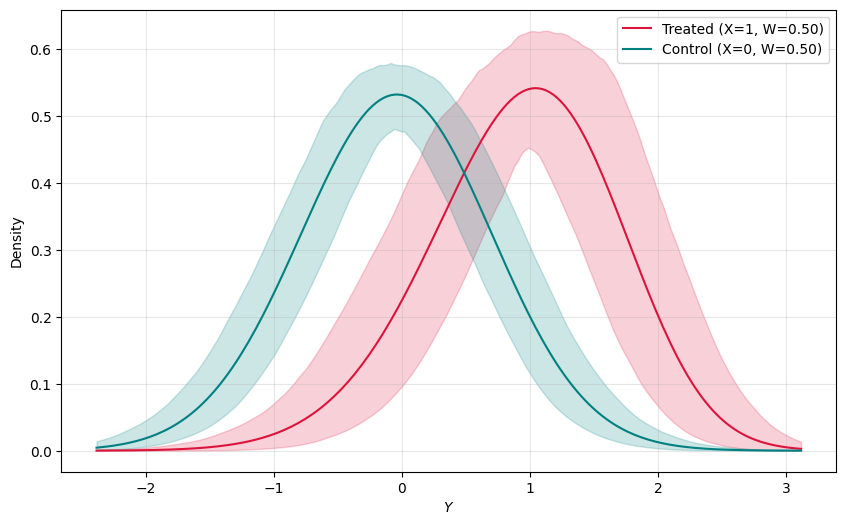

In [55]:
import matplotlib.pyplot as plt

w_val = 0.5
y_grid = np.linspace(y.min() - 1, y.max() + 1, 200)
T_fwd, B_post = 1000, 500

def get_density_stats(x_val):
    z_target = jnp.tile(jnp.array([[float(x_val), w_val]]), (len(y_grid), 1))
    _, logpdf_pr = predictive_resample_cregression(
        fit, jnp.array(Z), jnp.array(y_grid), z_target, B_post, T_fwd, seed=42
    )
    pdfs = jnp.exp(logpdf_pr)
    return {
        'mean': np.array(jnp.mean(pdfs, axis=0)).flatten(),
        'low':  np.array(jnp.quantile(pdfs, 0.025, axis=0)).flatten(),
        'high': np.array(jnp.quantile(pdfs, 0.975, axis=0)).flatten()
    }

res_t = get_density_stats(1)  # Treated
res_c = get_density_stats(0)  # Control

plt.figure(figsize=(10, 6))

# Plot Treated Group
plt.plot(y_grid, res_t['mean'], color='crimson', label=f'Treated (X=1, W={w_val:.2f})')
plt.fill_between(y_grid, res_t['low'], res_t['high'], color='crimson', alpha=0.2)

# Plot Control Group
plt.plot(y_grid, res_c['mean'], color='teal', label=f'Control (X=0, W={w_val:.2f})')
plt.fill_between(y_grid, res_c['low'], res_c['high'], color='teal', alpha=0.2)

plt.xlabel('$Y$')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Predicting...
Prediction time: 0.025s
Predictive resampling...
Predictive resampling time: 0.314s
Predicting...
Prediction time: 0.023s
Predictive resampling...
Predictive resampling time: 0.28s
Predicting...
Prediction time: 0.013s
Predictive resampling...
Predictive resampling time: 0.287s
Predicting...
Prediction time: 0.025s
Predictive resampling...
Predictive resampling time: 0.282s
Predicting...
Prediction time: 0.014s
Predictive resampling...
Predictive resampling time: 0.282s
Predicting...
Prediction time: 0.024s
Predictive resampling...
Predictive resampling time: 0.398s
Predicting...
Prediction time: 0.013s
Predictive resampling...
Predictive resampling time: 0.284s
Predicting...
Prediction time: 0.023s
Predictive resampling...
Predictive resampling time: 0.3s
Predicting...
Prediction time: 0.013s
Predictive resampling...
Predictive resampling time: 0.296s
Predicting...
Prediction time: 0.024s
Predictive resampling...
Predictive resampling time: 0.279s
Predicting...
Predictio

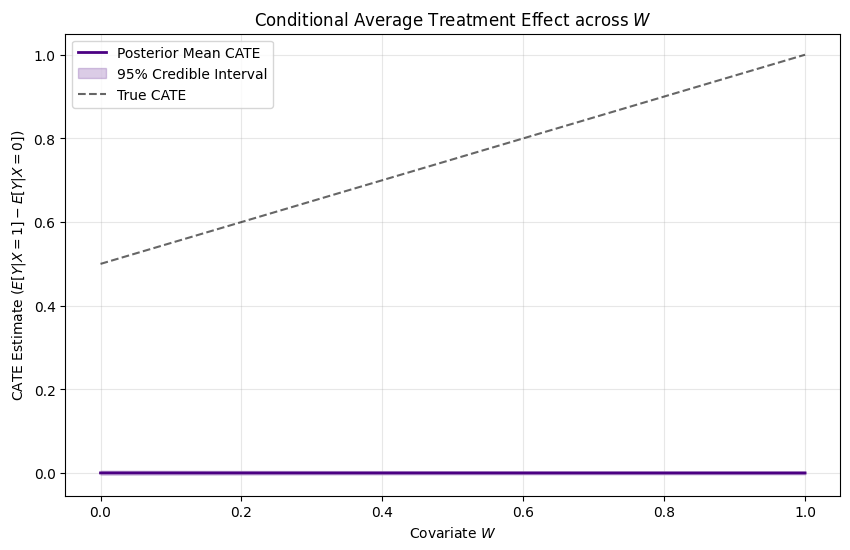

In [ ]:

# 1. Setup grids
w_range = np.linspace(0, 1, 10)
y_grid = np.linspace(y.min() - 1, y.max() + 1, 200)
dy = y_grid[1] - y_grid[0]
T_fwd, B_post = 500, 200

cate_means, cate_low, cate_high = [], [], []

# 2. Loop through w to compute CATE distribution
for wv in w_range:
    # Resample for Treated (X=1)
    z1 = jnp.tile(jnp.array([[1.0, wv]]), (len(y_grid), 1))
    _, lp1 = predictive_resample_cregression(fit, jnp.array(Z), jnp.array(y_grid), z1, B_post, T_fwd, seed=42)
    e1 = jnp.sum(jnp.exp(lp1) * y_grid * dy, axis=1)

    # Resample for Control (X=0)
    z0 = jnp.tile(jnp.array([[0.0, wv]]), (len(y_grid), 1))
    _, lp0 = predictive_resample_cregression(fit, jnp.array(Z), jnp.array(y_grid), z0, B_post, T_fwd, seed=42)
    e0 = jnp.sum(jnp.exp(lp0) * y_grid * dy, axis=1)

    # CATE distribution for this w
    diff = e1 - e0
    cate_means.append(np.mean(diff))
    cate_low.append(np.quantile(diff, 0.025))
    cate_high.append(np.quantile(diff, 0.975))

# 3. Plotting
plt.figure(figsize=(10, 6))
plt.plot(w_range, cate_means, color='indigo', lw=2, label='Posterior Mean CATE')
plt.fill_between(w_range, cate_low, cate_high, color='indigo', alpha=0.2, label='95% Credible Interval')

# True CATE from the generate_data function: 0.5 * (1 + W)
plt.plot(w_range, 0.5 * (1 + w_range), 'k--', alpha=0.6, label='True CATE')

plt.xlabel('Covariate $W$')
plt.ylabel('CATE Estimate ($E[Y|X=1] - E[Y|X=0]$)')
plt.title('Conditional Average Treatment Effect across $W$')
plt.legend()
plt.grid(alpha=0.3)
plt.show()